# 09_cnn_model_transfer_learning
Train and evaluate a CNN transfer-learning model using the same locked train/valid/test split. The notebook avoids color jitter and uses only small geometric augmentation.

## Input handling
This version can use `preprocess_manifest.csv` from Notebook 05, or rebuild the CNN image manifest from Notebook 06 outputs. It also searches for ZIP files uploaded to `/content` and repairs image paths from previous Colab sessions.

In [1]:

from pathlib import Path
import os, json, shutil, zipfile, hashlib, warnings, math, random, glob
from datetime import datetime, timezone
import pandas as pd
import numpy as np

BASE_DIR = Path(os.environ.get("THERMO_BASE_DIR", "/content"))
PROJECT_NAME = "project_thermography_equine"
PROJECT_ROOT = BASE_DIR / PROJECT_NAME
DATA_ROOT = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_ROOT / "raw"
SPLIT_DATA_DIR = DATA_ROOT / "dataset_split"
METADATA_DIR = DATA_ROOT / "metadata"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CONFIG_DIR = OUTPUT_ROOT / "config"
REPORTS_DIR = OUTPUT_ROOT / "reports"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
MODELS_DIR = OUTPUT_ROOT / "models"
MODEL_SELECTION_DIR = OUTPUT_ROOT / "model_selection"
PROCESSED_DIR = DATA_ROOT / "processed"
CLEAN_IMAGE_DIR = PROCESSED_DIR / "clean_images"
FEATURES_DIR = OUTPUT_ROOT / "features"

for p in [PROJECT_ROOT, DATA_ROOT, RAW_DATA_DIR, SPLIT_DATA_DIR, METADATA_DIR, ANNOTATIONS_DIR,
          OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR,
          MODEL_SELECTION_DIR, PROCESSED_DIR, CLEAN_IMAGE_DIR, FEATURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SEARCH_ROOTS = [BASE_DIR, Path('/mnt/data')]

def _existing_roots():
    return [p for p in SEARCH_ROOTS if p.exists()]

def _safe_copy(src: Path, dst: Path, overwrite: bool = False):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.resolve() == dst.resolve():
        return dst
    if overwrite or not dst.exists():
        shutil.copy2(src, dst)
    return dst

def find_first(patterns, roots=None, exclude_dirs=(".ipynb_checkpoints",)):
    roots = roots or _existing_roots()
    for root in roots:
        for pattern in patterns:
            for p in sorted(root.rglob(pattern)):
                if any(part in exclude_dirs for part in p.parts):
                    continue
                if p.is_file():
                    return p
    return None

def recover_notebook06_outputs():
    """Recover outputs from Notebook 06 if the user uploaded them to /content instead of project outputs/config."""
    targets = {
        "classical_features.csv": ["classical_features.csv", "classical_features*.csv"],
        "classical_feature_metadata.json": ["classical_feature_metadata.json"],
        "classical_feature_summary.csv": ["classical_feature_summary.csv"],
    }
    recovered = {}
    for target, patterns in targets.items():
        dst = CONFIG_DIR / target
        if dst.exists():
            recovered[target] = str(dst)
            continue
        src = find_first(patterns)
        if src is None:
            recovered[target] = None
            continue
        _safe_copy(src, dst)
        if target.endswith('.csv'):
            _safe_copy(src, FEATURES_DIR / target)
        recovered[target] = str(src)
    meta_path = CONFIG_DIR / "classical_feature_metadata.json"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))

        if meta.get("clinical_label_source") == "folder_structure":
            meta["clinical_label_source"] = "expert_curated_folder_structure_based_on_clinical_assessment"
            meta["clinical_label_source_note"] = (
                "Folder structure stores labels assigned by veterinary specialists before model development; "
                "folder names are a technical representation, not an independent diagnostic criterion."
            )
            meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    return recovered

def load_classical_features_and_metadata():
    recovered = recover_notebook06_outputs()
    features_path = CONFIG_DIR / "classical_features.csv"
    metadata_path = CONFIG_DIR / "classical_feature_metadata.json"
    if not features_path.exists() or not metadata_path.exists():
        raise FileNotFoundError(
            "Notebook 06 outputs are missing. Upload classical_features.csv and classical_feature_metadata.json, "
            "or run Notebook 06 before this notebook. Recovery status: " + json.dumps(recovered, indent=2)
        )
    features = pd.read_csv(features_path)
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    feature_columns = metadata.get("feature_columns", [])
    required = {"horse_id", "split", "label_clinical", "label_binary"}
    missing_required = sorted(required - set(features.columns))
    if missing_required:
        raise KeyError("classical_features.csv is missing required columns: " + ", ".join(missing_required))
    missing_features = [c for c in feature_columns if c not in features.columns]
    if missing_features:
        raise KeyError("Feature columns listed in metadata are absent from classical_features.csv: " + ", ".join(missing_features[:20]))
    allowed_splits = {"train", "valid", "test"}
    bad_splits = sorted(set(features["split"].dropna().astype(str)) - allowed_splits)
    if bad_splits:
        raise ValueError("Unexpected split labels: " + ", ".join(bad_splits))
    overlap = []
    for a in allowed_splits:
        for b in allowed_splits:
            if a < b:
                ia = set(features.loc[features["split"] == a, "horse_id"].astype(str))
                ib = set(features.loc[features["split"] == b, "horse_id"].astype(str))
                common = ia & ib
                if common:
                    overlap.append((a, b, len(common), sorted(list(common))[:5]))
    if overlap:
        raise ValueError("Horse-level leakage detected across splits: " + repr(overlap))
    leakage_like = [c for c in feature_columns if any(token in c.lower() for token in ["hotspot", "annotation", "label", "split", "horse_id", "image_name"])]
    if leakage_like:
        raise ValueError("Potential leakage columns found among predictors: " + ", ".join(leakage_like))
    print("Project root:", PROJECT_ROOT)
    print("Config dir:", CONFIG_DIR)
    print("Loaded Notebook 06 feature table:", features.shape)
    print("Clinical label source:", metadata.get("clinical_label_source"))
    display(features.groupby(["split", "label_clinical"]).size().reset_index(name="n"))
    return features, metadata, feature_columns


In [2]:
def extract_candidate_zips():
    zip_paths = []
    for root in _existing_roots():
        zip_paths.extend(sorted(root.glob("*.zip")))
    extracted = []
    for z in zip_paths:
        name = z.name.lower()
        if any(token in name for token in ["clean", "preprocess", "processed", "image", "dataset_split", "raw"]):
            target = PROJECT_ROOT / "_uploaded_zip_extracts" / z.stem
            target.mkdir(parents=True, exist_ok=True)
            marker = target / ".extracted"
            if not marker.exists():
                with zipfile.ZipFile(z, "r") as zip_ref:
                    zip_ref.extractall(target)
                marker.write_text(datetime.now(timezone.utc).isoformat(), encoding="utf-8")
            extracted.append(str(target))
    return extracted

def build_or_load_image_manifest():
    recovered = recover_notebook06_outputs()
    extract_candidate_zips()
    preprocess_path = CONFIG_DIR / "preprocess_manifest.csv"
    if preprocess_path.exists():
        manifest = pd.read_csv(preprocess_path)
    else:

        features, feature_metadata, feature_columns = load_classical_features_and_metadata()
        manifest = features.copy()
        if "clean_image_path" not in manifest.columns:
            if "feature_image_path" in manifest.columns:
                manifest["clean_image_path"] = manifest["feature_image_path"]
            elif "relative_image_path" in manifest.columns:
                manifest["clean_image_path"] = manifest["relative_image_path"].apply(lambda x: str(CLEAN_IMAGE_DIR / str(x)))
            else:
                raise KeyError("Cannot infer clean_image_path from Notebook 06 outputs.")
        manifest.to_csv(preprocess_path, index=False)
    if "included_in_final_analysis" in manifest.columns:
        manifest = manifest[manifest["included_in_final_analysis"].astype(bool)].copy()
    required_cols = ["clean_image_path", "label_binary", "split", "healthy_with_expert_hotspot"]
    missing_cols = [c for c in required_cols if c not in manifest.columns]
    if missing_cols:
        raise KeyError("Image manifest is missing required columns: " + ", ".join(missing_cols))

    image_index = {}
    search_dirs = [PROJECT_ROOT, CLEAN_IMAGE_DIR, BASE_DIR, Path('/mnt/data')]
    for root in search_dirs:
        if root.exists():
            for ext in ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff", "*.bmp"):
                for img in root.rglob(ext):
                    image_index.setdefault(img.name, img)
                    try:
                        rel = img.relative_to(CLEAN_IMAGE_DIR).as_posix()
                        image_index.setdefault(rel, img)
                    except Exception:
                        pass
    def repair_path(row):
        p = Path(str(row["clean_image_path"]))
        if p.exists():
            return str(p)
        candidates = []
        if "relative_image_path" in row and pd.notna(row["relative_image_path"]):
            candidates.extend([str(row["relative_image_path"]), Path(str(row["relative_image_path"])).name])
        if "image_name" in row and pd.notna(row["image_name"]):
            candidates.append(str(row["image_name"]))
        candidates.append(p.name)
        for key in candidates:
            if key in image_index:
                return str(image_index[key])
        return str(p)
    manifest["clean_image_path"] = manifest.apply(repair_path, axis=1)
    missing = manifest.loc[~manifest["clean_image_path"].apply(lambda x: Path(str(x)).exists()), ["image_name", "clean_image_path"] if "image_name" in manifest.columns else ["clean_image_path"]]
    if len(missing):
        raise FileNotFoundError(
            f"Could not locate {len(missing)} clean/preprocessed images. Upload the clean_images ZIP generated by Notebook 05 or run Notebook 05. "
            f"First missing rows:\n{missing.head(10).to_string(index=False)}"
        )
    if int(manifest["healthy_with_expert_hotspot"].astype(bool).sum()) != 6:
        warnings.warn("Expected 6 healthy images with expert-marked hotspots retained; check consistency with Notebook 06.")
    manifest.to_csv(CONFIG_DIR / "cnn_image_manifest_resolved.csv", index=False)
    print("Rows:", len(manifest))
    display(manifest.groupby(["split", "label_clinical"]).size().reset_index(name="n"))
    return manifest


In [3]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from torchvision import models, transforms
    from PIL import Image
    from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, roc_curve
    import matplotlib.pyplot as plt
except Exception as e:
    raise ImportError("This notebook requires PyTorch, torchvision, PIL, sklearn and matplotlib in Colab.") from e

manifest = build_or_load_image_manifest()


Rows: 347


,split,label_clinical,n
0,test,healthy,40
1,test,pathological,13
2,train,healthy,179
3,train,pathological,63
4,valid,healthy,38
5,valid,pathological,14


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = int(os.environ.get("THERMO_CNN_SIZE", 224))
BATCH_SIZE = int(os.environ.get("THERMO_BATCH_SIZE", 16))
EPOCHS = int(os.environ.get("THERMO_EPOCHS", 10))
LR = float(os.environ.get("THERMO_LR", 1e-4))
MODEL_NAME = os.environ.get("THERMO_CNN_MODEL", "resnet18")
NUM_WORKERS = int(os.environ.get("THERMO_NUM_WORKERS", 0))
print("Device:", DEVICE, "Epochs:", EPOCHS, "Batch size:", BATCH_SIZE)

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=5),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ThermographyDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["clean_image_path"]).convert("RGB")
        x = self.transform(img)
        y = torch.tensor(int(row["label_binary"]), dtype=torch.float32)
        return x, y, str(row.get("image_name", Path(row["clean_image_path"]).name))

train_df = manifest[manifest["split"] == "train"].copy()
valid_df = manifest[manifest["split"] == "valid"].copy()
test_df = manifest[manifest["split"] == "test"].copy()
for split_name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    if df.empty:
        raise ValueError(f"{split_name} split is empty.")

train_loader = DataLoader(ThermographyDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = DataLoader(ThermographyDataset(valid_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(ThermographyDataset(test_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Device: cpu Epochs: 10 Batch size: 16


In [5]:
def build_model():
    if MODEL_NAME == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, 1)
    else:
        raise ValueError(f"Unsupported CNN model: {MODEL_NAME}")
    return model

model = build_model().to(DEVICE)
class_counts = train_df["label_binary"].value_counts().to_dict()
pos_weight = torch.tensor([class_counts.get(0, 1) / max(class_counts.get(1, 1), 1)], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

def run_epoch(loader, train_mode=False):
    model.train(train_mode)
    losses, probs, labels, names = [], [], [], []
    for x, y, image_names in loader:
        x = x.to(DEVICE); y = y.to(DEVICE)
        if train_mode:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train_mode):
            logits = model(x).squeeze(1)
            loss = criterion(logits, y)
            if train_mode:
                loss.backward()
                optimizer.step()
        losses.append(float(loss.item()))
        probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        labels.extend(y.detach().cpu().numpy().astype(int).tolist())
        names.extend(list(image_names))
    return float(np.mean(losses)), np.array(labels), np.array(probs), names

best_auc = -np.inf
best_path = MODELS_DIR / f"cnn_{MODEL_NAME}_best.pt"
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_y, train_p, _ = run_epoch(train_loader, train_mode=True)
    valid_loss, valid_y, valid_p, _ = run_epoch(valid_loader, train_mode=False)
    valid_auc = roc_auc_score(valid_y, valid_p) if len(np.unique(valid_y)) == 2 else np.nan
    row = {"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, "valid_roc_auc": float(valid_auc)}
    history.append(row)
    print(row)
    if np.isfinite(valid_auc) and valid_auc > best_auc:
        best_auc = valid_auc
        torch.save({"model_state_dict": model.state_dict(), "epoch": epoch, "valid_roc_auc": float(valid_auc), "model_name": MODEL_NAME}, best_path)

if not best_path.exists():
    raise RuntimeError("No valid CNN checkpoint was saved; check validation labels and training run.")
pd.DataFrame(history).to_csv(REPORTS_DIR / "cnn_training_history.csv", index=False)
pd.DataFrame(history).to_csv(CONFIG_DIR / "cnn_training_history.csv", index=False)
print("Best validation AUC:", best_auc, "saved to", best_path)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 67.6MB/s]


{'epoch': 1, 'train_loss': 0.8905456215143204, 'valid_loss': 1.5269845351576805, 'valid_roc_auc': 0.7255639097744361}
{'epoch': 2, 'train_loss': 0.5454696211963892, 'valid_loss': 1.2090625911951065, 'valid_roc_auc': 0.6917293233082706}
{'epoch': 3, 'train_loss': 0.39118035743013024, 'valid_loss': 1.2718163430690765, 'valid_roc_auc': 0.7086466165413534}
{'epoch': 4, 'train_loss': 0.2832219093106687, 'valid_loss': 1.9978844746947289, 'valid_roc_auc': 0.7048872180451128}
{'epoch': 5, 'train_loss': 0.18245691782794893, 'valid_loss': 1.9396468736231327, 'valid_roc_auc': 0.7105263157894737}
{'epoch': 6, 'train_loss': 0.1561131061753258, 'valid_loss': 1.44170081615448, 'valid_roc_auc': 0.7161654135338347}
{'epoch': 7, 'train_loss': 0.19775187014602125, 'valid_loss': 1.7672174870967865, 'valid_roc_auc': 0.7725563909774436}
{'epoch': 8, 'train_loss': 0.09573337237816304, 'valid_loss': 1.5228973180055618, 'valid_roc_auc': 0.7781954887218046}
{'epoch': 9, 'train_loss': 0.09964919328922406, 'valid

,split,n,n_positive,n_negative,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,f1,sensitivity,specificity,tn,fp,fn,tp
0,train,242,63,179,0.5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179,0,0,63
1,valid,52,14,38,0.5,0.778195,0.549525,0.711538,0.689850,0.545455,0.642857,0.736842,28,10,5,9
2,test,53,13,40,0.5,0.925000,0.798452,0.830189,0.809615,0.689655,0.769231,0.850000,34,6,3,10


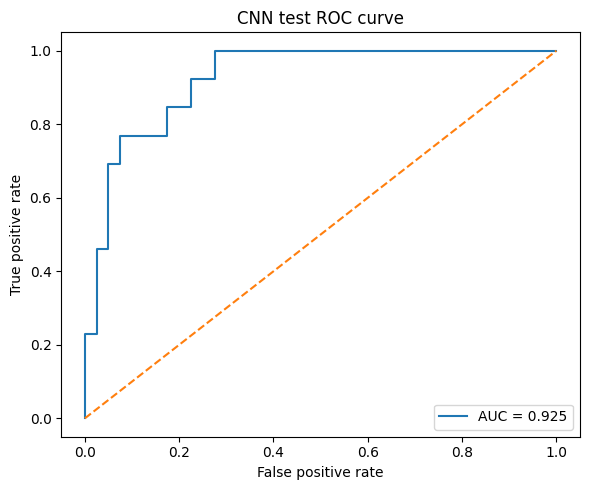

449

In [6]:
# Evaluate best model on all splits.
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

def eval_split(loader, df, split_name, threshold=0.5):
    loss, y, p, names = run_epoch(loader, train_mode=False)
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    metrics = {
        "split": split_name,
        "n": int(len(y)),
        "n_positive": int(y.sum()),
        "n_negative": int((1-y).sum()),
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
        "average_precision": float(average_precision_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
        "accuracy": float(accuracy_score(y, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "sensitivity": float(tp/(tp+fn)) if (tp+fn) else np.nan,
        "specificity": float(tn/(tn+fp)) if (tn+fp) else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    keep_cols = [c for c in ["horse_id", "image_name", "split", "label_clinical", "label_binary", "healthy_with_expert_hotspot", "clean_image_path"] if c in df.columns]
    out = df[keep_cols].copy()
    out["cnn_probability_pathological"] = p
    out["cnn_predicted_label_binary"] = pred
    return metrics, out

rows, preds = [], []
for split_name, loader, df in [("train", train_loader, train_df), ("valid", valid_loader, valid_df), ("test", test_loader, test_df)]:
    m, pr = eval_split(loader, df, split_name)
    rows.append(m); preds.append(pr)
cnn_metrics = pd.DataFrame(rows)
cnn_predictions = pd.concat(preds, ignore_index=True)
display(cnn_metrics)

cnn_metrics.to_csv(CONFIG_DIR / "cnn_model_metrics.csv", index=False)
cnn_metrics.to_csv(REPORTS_DIR / "cnn_model_metrics.csv", index=False)
cnn_metrics.to_csv(TABLES_DIR / "table_cnn_model_metrics.csv", index=False)
cnn_predictions.to_csv(CONFIG_DIR / "cnn_model_predictions.csv", index=False)
cnn_predictions.to_csv(REPORTS_DIR / "cnn_model_predictions.csv", index=False)

y_test = test_df["label_binary"].astype(int).values
p_test = cnn_predictions[cnn_predictions["split"] == "test"]["cnn_probability_pathological"].values
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, p_test):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("CNN test ROC curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_cnn_test_roc.png", dpi=300)
plt.show()

cnn_record = {
    "model_name": MODEL_NAME,
    "checkpoint_path": str(best_path),
    "best_valid_auc": float(best_auc),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "img_size": int(IMG_SIZE),
    "color_jitter_used": False,
    "geometric_augmentation_only": True,
    "decision_threshold": 0.5,
    "threshold_selection_method": "fixed_0.5_for_cnn; no test-set threshold tuning",
    "test_set_used_for_model_selection": False,
}
(CONFIG_DIR / "cnn_model_record.json").write_text(json.dumps(cnn_record, indent=2), encoding="utf-8")
(REPORTS_DIR / "cnn_model_record.json").write_text(json.dumps(cnn_record, indent=2), encoding="utf-8")
